In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import shap
import warnings
warnings.filterwarnings('ignore')


/Users/aryanaman/Desktop/DataMining_Assignment/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data = pd.read_csv('/Users/aryanaman/Downloads/diabetes_dataset.csv')

print(data.head())

print(data.isnull().sum())

print(data.info())


   year  gender   age location  race:AfricanAmerican  race:Asian  \
0  2020  Female  32.0  Alabama                     0           0   
1  2015  Female  29.0  Alabama                     0           1   
2  2015    Male  18.0  Alabama                     0           0   
3  2015    Male  41.0  Alabama                     0           0   
4  2016  Female  52.0  Alabama                     1           0   

   race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0               0              0           1             0              0   
1               0              0           0             0              0   
2               0              0           1             0              0   
3               1              0           0             0              0   
4               0              0           0             0              0   

  smoking_history    bmi  hbA1c_level  blood_glucose_level  diabetes  
0           never  27.32          5.0                  10

In [ ]:
print(f"Dataset shape: {data.shape}")
print("Column names:", data.columns.tolist())

print("\nDataset Info:")
print(data.info())

print("\nDescriptive Statistics:")
print(data.describe())


Dataset shape: (100000, 16)
Column names: ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          

In [ ]:
print("\nMissing Values:")
print(data.isnull().sum())



Missing Values:
year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64


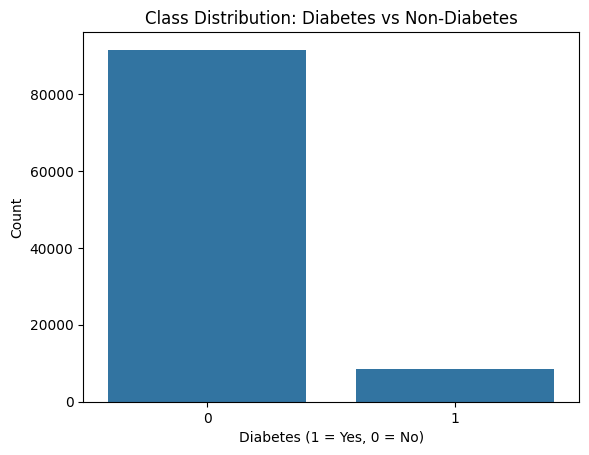


Diabetes Class Distribution (%):
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


In [ ]:
sns.countplot(data=data, x='diabetes')
plt.title("Class Distribution: Diabetes vs Non-Diabetes")
plt.xlabel("Diabetes (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

diabetes_counts = data['diabetes'].value_counts(normalize=True) * 100
print(f"\nDiabetes Class Distribution (%):\n{diabetes_counts}")


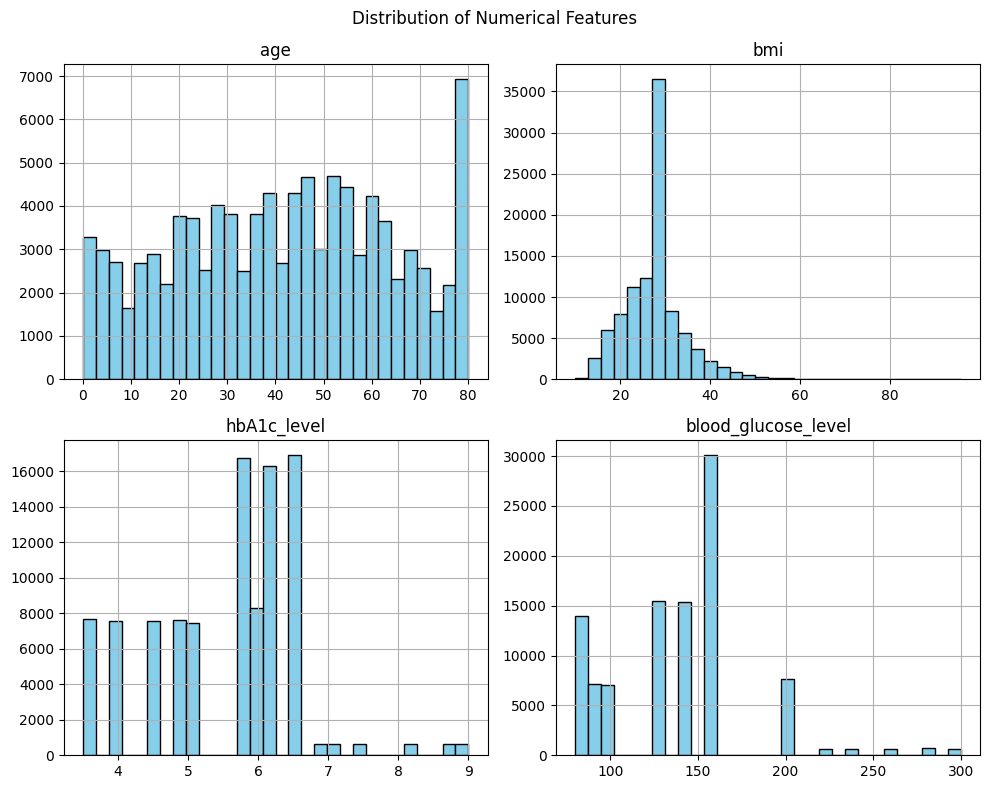

In [ ]:
numerical_cols = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

data[numerical_cols].hist(bins=30, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()


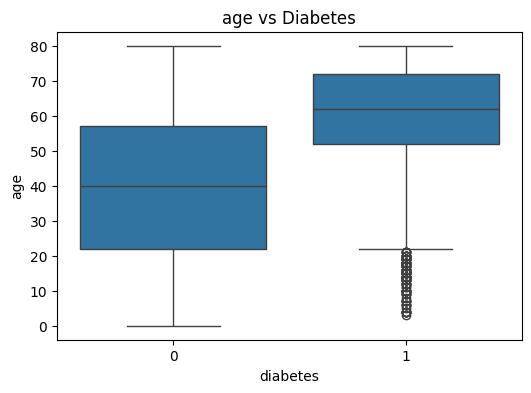

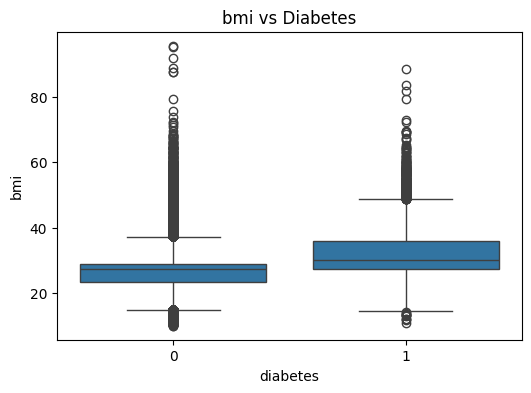

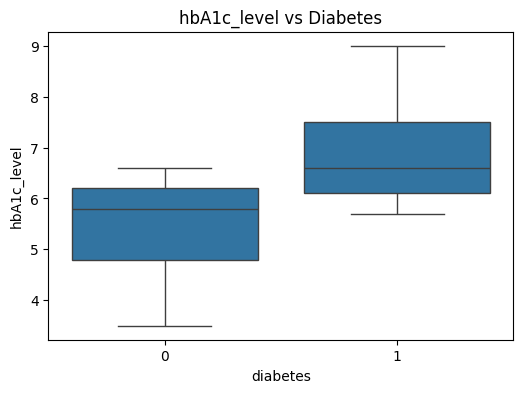

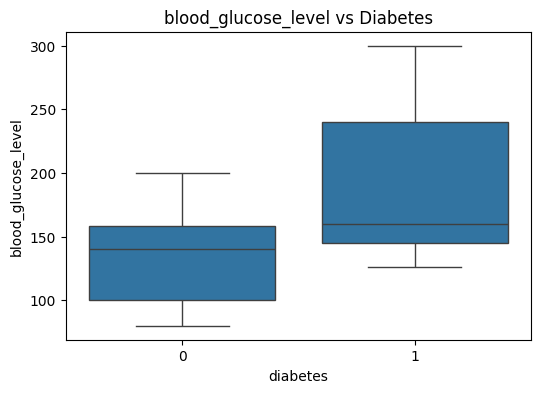

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='diabetes', y=col, data=data)
    plt.title(f'{col} vs Diabetes')
    plt.show()


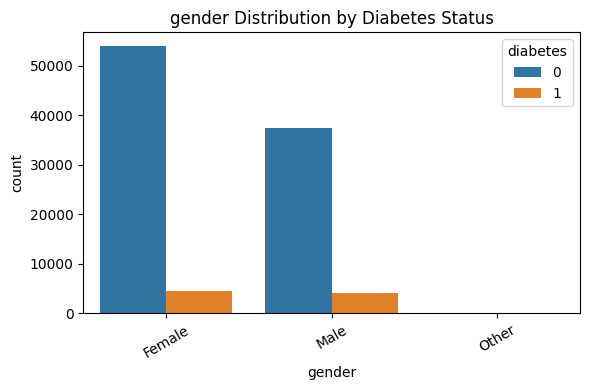

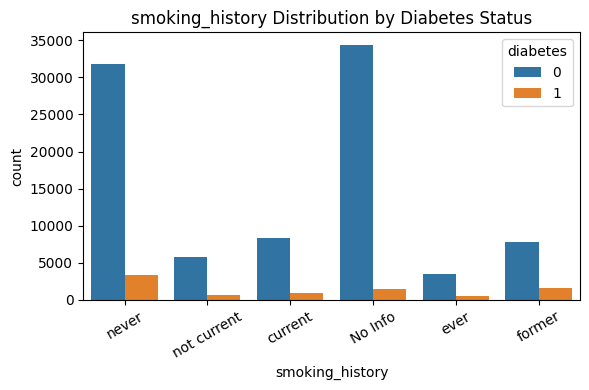

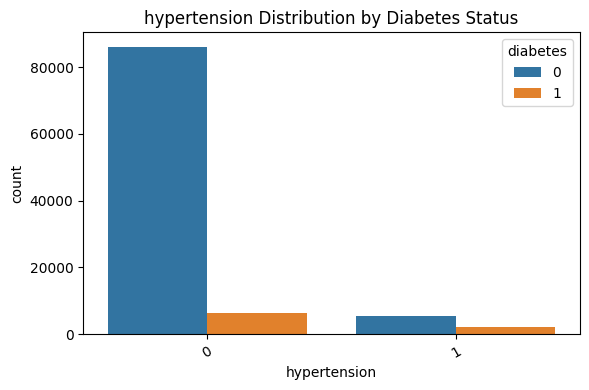

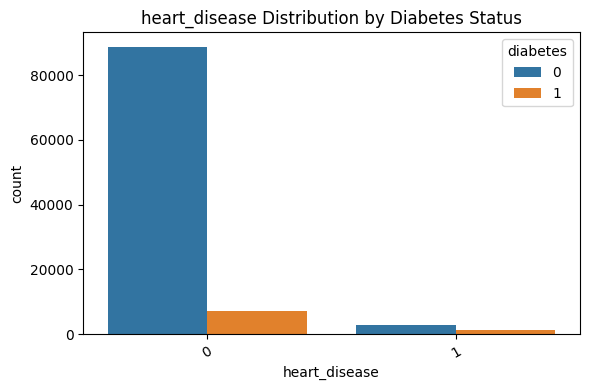

In [14]:
categorical_cols = ['gender', 'smoking_history', 'hypertension', 'heart_disease']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=data, x=col, hue='diabetes')
    plt.title(f"{col} Distribution by Diabetes Status")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


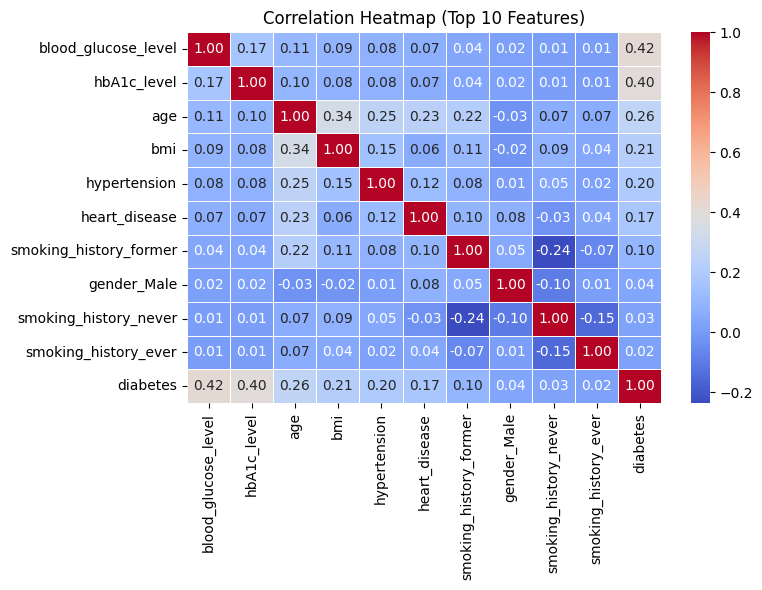

In [ ]:
encoded_data = pd.get_dummies(data, drop_first=True)

corr_matrix = encoded_data.corr()

top_n = 10
top_corr = corr_matrix['diabetes'].abs().sort_values(ascending=False).drop('diabetes').head(top_n).index

filtered_features = top_corr.tolist() + ['diabetes']
filtered_corr_matrix = corr_matrix.loc[filtered_features, filtered_features]

plt.figure(figsize=(8, 6))
sns.heatmap(filtered_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title(f"Correlation Heatmap (Top {top_n} Features)")
plt.tight_layout()
plt.show()


In [ ]:
data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop('diabetes', axis=1)
y = data_encoded['diabetes']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} trained successfully.')


Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


In [18]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f'\n{name} Evaluation Metrics:')
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall: {rec:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'ROC AUC: {roc_auc:.4f}')



Logistic Regression Evaluation Metrics:
Accuracy: 0.9608
Precision: 0.8677
Recall: 0.6365
F1 Score: 0.7343
ROC AUC: 0.9618

Decision Tree Evaluation Metrics:
Accuracy: 0.9561
Precision: 0.7455
Recall: 0.7341
F1 Score: 0.7398
ROC AUC: 0.8554

Random Forest Evaluation Metrics:
Accuracy: 0.9724
Precision: 0.9940
Recall: 0.6788
F1 Score: 0.8067
ROC AUC: 0.9585


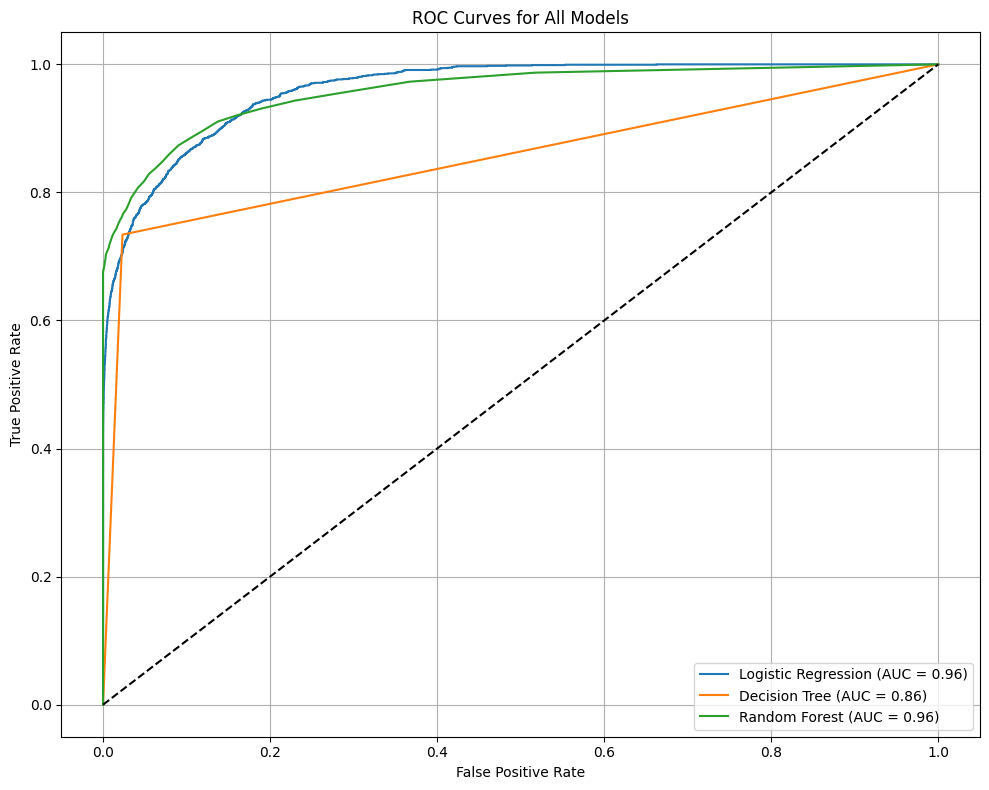

In [ ]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()
